# SINASC 2024 — robustez e auditoria metodológica

## 1. Por que a Fase 3 existe

Auditar o AIPW, a concentração da influência e a independência geográfica. **Não buscar um resultado mais favorável.**

Este notebook valida as predições persistidas e apresenta a execução integral. Os ajustes pesados são reproduzidos com `python -m src.executa_robustez_fase3`, na `.venv` deste projeto. Não há ajuste oculto ao abrir o notebook.

Descrição, performance preditiva dos nuisances e interpretação causal permanecem separadas. Fontes: Parquet SINASC 2024 e JSONs Fase 2/3; hashes e SQL estão nos artefatos de auditoria.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

raiz = next(p for p in (Path.cwd(), Path.cwd().parent) if (p/'src').exists()).resolve()
sys.path.insert(0, str(raiz))
assert Path(sys.executable).resolve() == (raiz/'.venv/Scripts/python.exe').resolve(), 'Ative a .venv do projeto'
from src.visualizacao_ipt import configurar_plotly, aplicar_tema_ipt
configurar_plotly()
pasta = raiz/'outputs/diagnostics'
ler = lambda nome: json.loads((pasta/nome).read_text(encoding='utf-8'))
historico = ler('fase2_aipw.json')
influencia = ler('fase3_influencia.json')
cluster = ler('fase3_cluster.json')
geografico = ler('fase3_crossfit_geografico.json')
monte_carlo = ler('fase3_monte_carlo.json')
sens = ler('fase3_sensibilidades.json')
gate = ler('fase3_gate.json')
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)

def mostrar(fig, titulo, nome, altura=600):
    aplicar_tema_ipt(fig, titulo)
    fig.update_layout(width=1100, height=altura, margin=dict(l=115,r=50,t=100,b=110))
    fig.update_xaxes(automargin=True)
    fig.update_yaxes(automargin=True)
    arquivo = raiz/'outputs/figures'/('fase3_'+nome+'.png')
    fig.write_image(arquivo)
    display(Image(filename=str(arquivo)))

colunas = ['especificacao','populacao','n','estimativa_pp','se_iid_pp','se_cluster_pp',
           'ic95_cluster_inferior_pp','ic95_cluster_superior_pp']
def tabela(resumo):
    display(pd.DataFrame(resumo['resultados'])[colunas].round(6))


In [2]:
display(Markdown('**Síntese:** '+gate['sintese']))
display(Markdown('**Revisão adicional:** `'+gate['gate']+'`. O gate histórico permanece `'+historico['gate']+'`.'))


**Síntese:** O veto automático pelo top 1% >50% de IF² é excessivamente conservador como diagnóstico de invalidade numérica/inferencial. AIPW histórico reconciliado, contribuição individual pequena, ajustes geográficos estáveis e simulação oráculo questionam esse veto. A inclusão de múltiplas muda a magnitude em cerca de 0,20 pp e define outro alvo. Seleção, confundimento e temporalidade continuam impedindo uma interpretação causal forte; o gate histórico não foi alterado.

**Revisão adicional:** `GATE_FASE2_EXCESSIVAMENTE_CONSERVADOR`. O gate histórico permanece `RESULTADO_NAO_INTERPRETAVEL`.

## 2. Resultado congelado da Fase 2

Unidade: registro de nascido vivo. População P1: gestação única, peso 500–6.000 g e MESPRENAT 1–9. T=1 meses 1–3; T=0 meses 4–9. Y=1 peso <2.500 g. Sete X congeladas; nenhuma feature municipal nova.


In [3]:
display(pd.DataFrame(historico['resultados'])[['especificacao','populacao','n','estimativa_pp','se_pp']].round(6))

,especificacao,populacao,n,estimativa_pp,se_pp
0,C1,sem_trimming,2251570,-1.340527,0.061994
1,C1,0.01_0.99,2251570,-1.340527,0.061994
2,C1,0.05_0.95,2103319,-1.382662,0.060840
3,C2,sem_trimming,2251570,-1.231456,0.061981
4,C2,0.01_0.99,2251570,-1.231456,0.061981
5,C2,0.05_0.95,2103319,-1.273369,0.060813


## 3. Auditoria da IF

`psi = m1−m0 + T(Y−m1)/e − (1−T)(Y−m0)/(1−e)`; `IF=psi−média(psi)`.

`SE_iid² = soma(IF²)/[N(N−1)]`. Implementação independente por grupos, tolerância absoluta 1e−12. A validação abaixo também recalcula o sandwich via DuckDB, verifica folds e compara hashes históricos.


In [4]:
from src.valida_resultados_fase3 import validar
validacao = validar(raiz)
assert validacao['status'] == 'APROVADO'
display(pd.DataFrame(influencia['reconciliacao']))


{
  "status": "APROVADO",
  "n": 2251570,
  "datas": {
    "datas_invalidas": 0,
    "fora_2024": 0,
    "minima": "2024-01-01 00:00:00",
    "maxima": "2024-12-31 00:00:00"
  },
  "cobertura_oof": "exatamente uma previsão por observação",
  "resultados_reconciliados": 6,
  "tolerancia_absoluta": 1e-12,
  "n_nan_predicoes": 0
}


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{
  "status": "APROVADO",
  "linhas_reconciliadas": 22,
  "tolerancia_absoluta": 1e-12,
  "sandwich_independente": "DuckDB GROUP BY; score centrado por registro",
  "fase2": {
    "status": "APROVADO",
    "n": 2251570,
    "datas": {
      "datas_invalidas": 0,
      "fora_2024": 0,
      "minima": "2024-01-01 00:00:00",
      "maxima": "2024-12-31 00:00:00"
    },
    "cobertura_oof": "exatamente uma previsão por observação",
    "resultados_reconciliados": 6,
    "tolerancia_absoluta": 1e-12,
    "n_nan_predicoes": 0
  },
  "populacoes": {
    "aleatorio": {
      "n": 2251570,
      "n_t1": 1942045,
      "n_t0": 309525
    },
    "geografico": {
      "n": 2251570,
      "n_t1": 1942045,
      "n_t0": 309525
    },
    "consprenat": {
      "n": 2250506,
      "n_t1": 1941385,
      "n_t0": 309121
    },
    "p0": {
      "n": 2254701,
      "n_t1": 1944812,
      "n_t0": 309889
    },
    "multiplas": {
      "n": 2304013,
      "n_t1": 1988680,
      "n_t0": 315333
    }
  },
  

,especificacao,populacao,n,delta_estimativa,delta_se,max_delta_psi,delta_top1
0,C1,sem_trimming,2251570,0.0,0.0,0.0,2.220446e-16
1,C1,0.01_0.99,2251570,0.0,0.0,0.0,2.220446e-16
2,C1,0.05_0.95,2103319,0.0,0.0,0.0,0.000000e+00
3,C2,sem_trimming,2251570,0.0,0.0,0.0,-1.110223e-16
4,C2,0.01_0.99,2251570,0.0,0.0,0.0,-1.110223e-16
5,C2,0.05_0.95,2103319,0.0,0.0,0.0,-2.220446e-16


## 4. Curva de concentração

Ordem **decrescente** de |IF|; X=fração acumulada de registros, Y=fração acumulada de IF². Não é Lorenz crescente convencional. Faixas são cumulativas, com N arredondado para cima.

Contribuição `soma(psi_top)/N` compõe a estimativa; `soma(IF_top)/N` é o desvio líquido centrado. Nenhuma delas é efeito causal dos registros extremos.


,especificacao,top_pct,n,fracao_if2,fracao_abs_if,contribuicao_psi_pp,contribuicao_if_pp
0,C1,0.01,226,0.070984,0.008107,-0.247728,-0.247593
1,C1,0.05,1126,0.219395,0.031406,-0.959778,-0.959107
2,C1,0.10,2252,0.323710,0.053368,-1.631133,-1.629793
3,C1,0.50,11258,0.638805,0.159694,-4.883577,-4.876874
4,C1,1.00,22516,0.787812,0.242131,-7.404465,-7.391060
5,C1,2.00,45032,0.848183,0.312934,-6.866572,-6.839762
6,C1,5.00,112579,0.896027,0.428068,-3.396185,-3.329158
7,C1,10.00,225157,0.955485,0.594045,1.605558,1.739611
8,C2,0.01,226,0.071336,0.008128,-0.248380,-0.248256
9,C2,0.05,1126,0.219784,0.031420,-0.960265,-0.959649


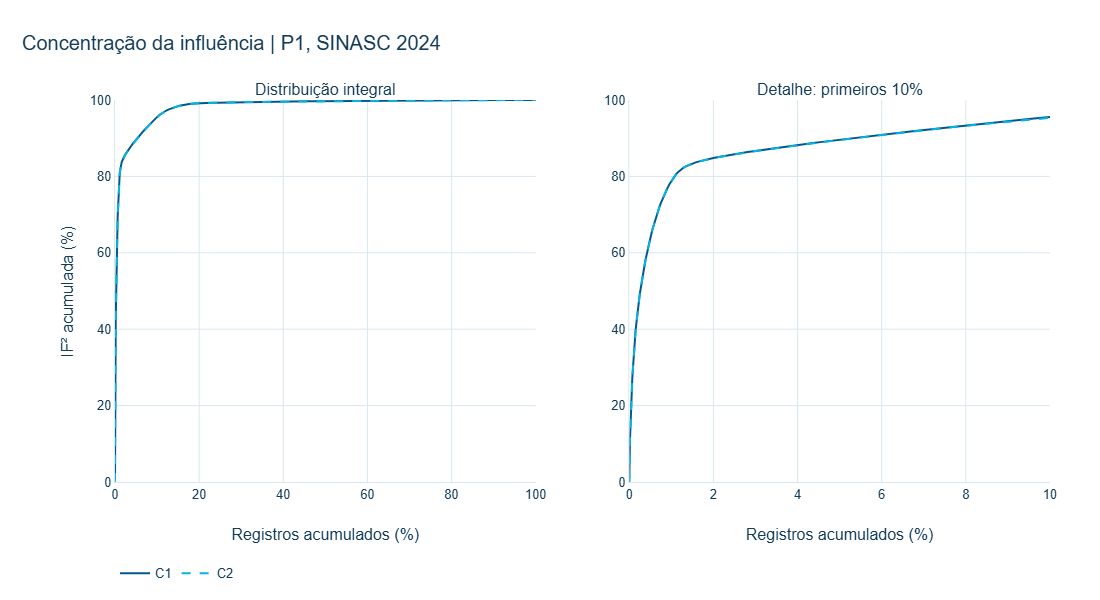

In [5]:
faixas = pd.DataFrame([dict(especificacao=s, **r) for s,d in influencia['especificacoes'].items() for r in d['faixas']])
display(faixas[['especificacao','top_pct','n','fracao_if2','fracao_abs_if','contribuicao_psi_pp','contribuicao_if_pp']].round(6))
fig = make_subplots(rows=1, cols=2, subplot_titles=['Distribuição integral','Detalhe: primeiros 10%'])
for s,d in influencia['especificacoes'].items():
    curva = d['curva']; x=100*np.array(curva['fracao_observacoes']); y=100*np.array(curva['fracao_if2'])
    for j in [1,2]:
        fig.add_scatter(x=x,y=y,mode='lines',name=s,legendgroup=s,showlegend=(j==1),
                        line=dict(color='#00598E' if s=='C1' else '#04B4E3',dash='solid' if s=='C1' else 'dash'),row=1,col=j)
fig.update_xaxes(title='Registros acumulados (%)',range=[0,100],row=1,col=1)
fig.update_xaxes(title='Registros acumulados (%)',range=[0,10],row=1,col=2)
fig.update_yaxes(title='IF² acumulada (%)',range=[0,100],row=1,col=1)
fig.update_yaxes(range=[0,100],row=1,col=2)
mostrar(fig,'Concentração da influência | P1, SINASC 2024','concentracao')


Top 1% concentra aproximadamente 78,8% de IF². A maior observação responde por menos de 0,06% da soma de IF²: concentração coletiva e dominância individual são diagnósticos diferentes.

## 5. Perfil dos extremos — descrição, não mecanismo causal

O top 1% é composto por controles e quase inteiramente por Y=1. No top 0,1%, a mediana de e é aproximadamente 0,939: a baixa probabilidade relevante é **1−e**, a chance do tratamento recebido pelos controles. Não confundir com propensity baixo.


In [6]:
display(faixas.loc[faixas.top_pct.isin([.1,1.,5.]),
    ['especificacao','top_pct','n','prop_t0','prop_t1','prop_y0','prop_y1']].round(6))
perfis = []
for s,d in influencia['especificacoes'].items():
    for pct in ['100.0','0.1','1.0','5.0']:
        r=d['perfis'][pct]
        perfis.append(dict(especificacao=s,top_pct=float(pct),n=r['n'],idade_mediana=r['idade']['0.5'],
                           e_mediano=r['propensity']['0.5'],e_p99=r['propensity']['0.99']))
display(pd.DataFrame(perfis).round(4))


,especificacao,top_pct,n,prop_t0,prop_t1,prop_y0,prop_y1
2,C1,0.1,2252,1.000000,0.000000,0.000000,1.000000
4,C1,1.0,22516,1.000000,0.000000,0.000400,0.999600
6,C1,5.0,112579,0.552679,0.447321,0.301850,0.698150
10,C2,0.1,2252,1.000000,0.000000,0.000000,1.000000
12,C2,1.0,22516,1.000000,0.000000,0.004086,0.995914
14,C2,5.0,112579,0.545466,0.454534,0.294646,0.705354


,especificacao,top_pct,n,idade_mediana,e_mediano,e_p99
0,C1,100.0,2251570,27.0,0.8734,0.9636
1,C1,0.1,2252,33.0,0.9394,0.9670
2,C1,1.0,22516,27.0,0.8563,0.9594
3,C1,5.0,112579,27.0,0.8435,0.9629
4,C2,100.0,2251570,27.0,0.8734,0.9636
5,C2,0.1,2252,33.0,0.9394,0.9670
6,C2,1.0,22516,27.0,0.8569,0.9609
7,C2,5.0,112579,27.0,0.8434,0.9629


In [7]:
# Perfil categórico completo: códigos preservados, sem imputar interpretação causal.
for variavel in ['ESCOLARIDADE_MAE','RACA_COR_MAE','SITUACAO_CONJUGAL','PARIDADE_CAT','PERDAS_FETAIS_CAT']:
    linhas=[]
    for s,d in influencia['especificacoes'].items():
        for pct in ['100.0','0.1','1.0','5.0']:
            linhas += [dict(especificacao=s,top_pct=pct,categoria=k,percentual=100*v['proporcao'])
                       for k,v in d['perfis'][pct]['categorias'][variavel].items()]
    display(Markdown('**'+variavel+'**'))
    display(pd.DataFrame(linhas).pivot(index='categoria',columns=['especificacao','top_pct'],values='percentual').round(2))


**ESCOLARIDADE_MAE**

especificacao     C1                          C2                     
top_pct        100.0    0.1    1.0    5.0  100.0    0.1    1.0    5.0
categoria                                                            
0               0.22    NaN   0.06   0.53   0.22    NaN   0.08   0.53
1               1.95    NaN   2.05   3.39   1.95    NaN   2.03   3.44
2              16.82   0.27  20.75  24.72  16.82   0.18  20.67  24.83
3              55.69  34.55  61.94  51.69  55.69  34.59  61.74  51.12
4               5.17   6.48   4.69   4.29   5.17   6.71   4.70   4.06
5              19.67  58.66   9.99  14.87  19.67  58.48  10.28  15.49
IGNORADO        0.48   0.04   0.52   0.51   0.48   0.04   0.51   0.52

**RACA_COR_MAE**

especificacao     C1                          C2                     
top_pct        100.0    0.1    1.0    5.0  100.0    0.1    1.0    5.0
categoria                                                            
1              33.43  58.48  29.20  29.01  33.43  58.66  29.39  28.71
2               7.94   3.51   9.63   9.81   7.94   3.60   9.65   9.91
3               0.46   0.53   0.40   0.38   0.46   0.53   0.40   0.39
4              55.73  35.92  58.71  57.39  55.73  35.79  58.49  57.58
5               1.19    NaN   0.59   1.92   1.19    NaN   0.59   1.94
IGNORADO        1.25   1.55   1.47   1.48   1.25   1.42   1.49   1.45

**SITUACAO_CONJUGAL**

especificacao     C1                          C2                     
top_pct        100.0    0.1    1.0    5.0  100.0    0.1    1.0    5.0
categoria                                                            
1              51.93   8.84  64.89  60.94  51.93   9.01  64.48  60.08
2              31.61  82.99  18.64  23.12  31.61  82.82  19.00  24.23
3               0.16   0.09   0.17   0.17   0.16   0.09   0.17   0.16
4               1.70   2.44   1.73   1.62   1.70   2.40   1.75   1.78
5              13.99   5.51  13.88  13.46  13.99   5.51  13.91  13.05
IGNORADO        0.61   0.13   0.68   0.70   0.61   0.18   0.69   0.69

**PARIDADE_CAT**

especificacao     C1                          C2                     
top_pct        100.0    0.1    1.0    5.0  100.0    0.1    1.0    5.0
categoria                                                            
0              36.91  54.48  39.13  37.88  36.91  55.15  39.09  35.28
1              63.09  45.52  60.87  62.12  63.09  44.85  60.91  64.72

**PERDAS_FETAIS_CAT**

especificacao     C1                          C2                     
top_pct        100.0    0.1    1.0    5.0  100.0    0.1    1.0    5.0
categoria                                                            
0              76.88  74.02  74.32  74.86  76.88  74.11  74.19  74.22
1              16.77  19.58  18.42  17.64  16.77  19.58  18.51  18.23
2_OU_MAIS       4.47   4.93   5.70   5.83   4.47   4.93   5.76   5.88
IGNORADO        1.88   1.47   1.56   1.67   1.88   1.38   1.53   1.67

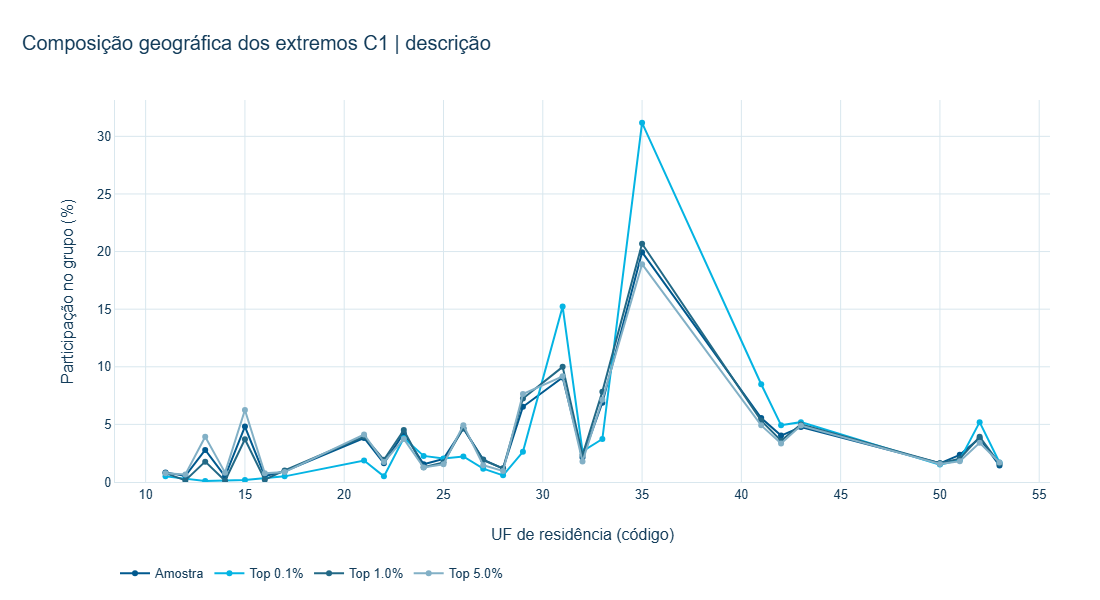

In [8]:
fig=go.Figure()
for pct in ['100.0','0.1','1.0','5.0']:
    d=influencia['especificacoes']['C1']['perfis'][pct]['categorias']['UF_RESIDENCIA']
    ufs=sorted(d)
    fig.add_scatter(x=ufs,y=[100*d[u]['proporcao'] for u in ufs],mode='lines+markers',name='Amostra' if pct=='100.0' else 'Top '+pct+'%')
fig.update_xaxes(title='UF de residência (código)')
fig.update_yaxes(title='Participação no grupo (%)',rangemode='tozero')
mostrar(fig,'Composição geográfica dos extremos C1 | descrição','perfil_uf')


## 6. Dependência por município

CODMUNRES é recuperado da mesma base em ordem de contador; chave única e datas validadas. Os 5.581 agrupamentos incluem 11 códigos de município não especificado (37 registros). Não são 5.581 municípios identificados. A exclusão desses códigos aparece como sensibilidade separada.


In [9]:
amostra=cluster['amostra']
display(pd.DataFrame([{k:v for k,v in amostra.items() if k not in ['sql','codigos_municipio_nao_especificado']}]).T)
r=cluster['resultados'][0]
display(pd.DataFrame([{'quantil':k,'N_cluster':v} for k,v in r['tamanhos'].items()]))
print('Clusters com N<10:',r['clusters_n_menor_10'],'| maior fração de N:',r['max_fracao_n'])
tabela(cluster['sensibilidade_sem_municipio_nao_especificado'])


,0
cenario,P1
n,2251570
n_t1,1942045
n_t0,309525
prevalencia,0.078949
n_clusters,5581
n_consprenat_zero,1064
n_multipla,0
n_peso_fora_p1,0
datas_invalidas,0


,quantil,N_cluster
0,0,1.0
1,0.01,11.0
2,0.05,20.0
3,0.5,117.0
4,0.95,1286.0
5,0.99,4604.0
6,1,116429.0


Clusters com N<10: 43 | maior fração de N: 0.05171014003561959


,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,C1,sem_trimming,2251533,-1.340996,0.061994,0.068286,-1.474863,-1.207129
1,C1,0.05_0.95,2103284,-1.383121,0.060841,0.068624,-1.517651,-1.248591
2,C2,sem_trimming,2251533,-1.231927,0.061982,0.067995,-1.365224,-1.098629
3,C2,0.05_0.95,2103284,-1.273831,0.060814,0.068368,-1.407859,-1.139802


## 7. SE iid versus cluster e bootstrap

`U_g=soma(IF_i no cluster g)`; `SE_cluster²=[G/(G−1)]×soma(U_g²)/N²`. IC por t com G−1 graus de liberdade. Pressupõe independência entre clusters e regularidade; não corrige confundimento.

Bootstrap: 500 sorteios de G clusters, com reposição, denominador N* variável. Nuisances fixos; não incorpora sua incerteza completa. Na Fase 2, a correção sandwich é sensibilidade, pois os folds originais misturam municípios.


,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,C1,sem_trimming,2251570,-1.340527,0.061994,0.068287,-1.474397,-1.206657
1,C1,0.05_0.95,2103319,-1.382662,0.060840,0.068626,-1.517196,-1.248127
2,C2,sem_trimming,2251570,-1.231456,0.061981,0.067997,-1.364757,-1.098155
3,C2,0.05_0.95,2103319,-1.273369,0.060813,0.068371,-1.407403,-1.139335


,especificacao,populacao,SE_boot_pp,IC_inferior_pp,IC_superior_pp
0,C1,sem_trimming,0.072235,-1.474935,-1.191432
1,C1,0.05_0.95,0.073294,-1.516978,-1.233590
2,C2,sem_trimming,0.072250,-1.364401,-1.084545
3,C2,0.05_0.95,0.073339,-1.404946,-1.120422


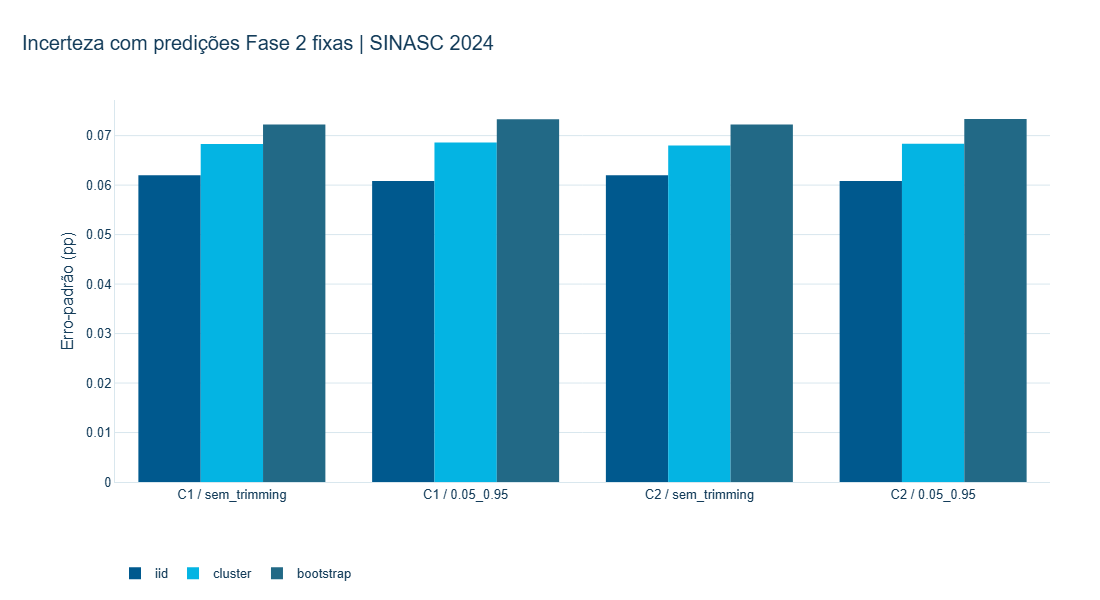

In [10]:
tabela(cluster)
boots=pd.DataFrame([dict(especificacao=r['especificacao'],populacao=r['populacao'],
                         SE_boot_pp=r['bootstrap']['se_bootstrap_pp'],
                         IC_inferior_pp=r['bootstrap']['ic95_percentil_pp'][0],
                         IC_superior_pp=r['bootstrap']['ic95_percentil_pp'][1]) for r in cluster['resultados']])
display(boots.round(6))
fig=go.Figure()
for nome,campo in [('iid','se_iid_pp'),('cluster','se_cluster_pp'),('bootstrap','SE_boot_pp')]:
    valores=boots[campo] if nome=='bootstrap' else [r[campo] for r in cluster['resultados']]
    fig.add_bar(x=[r['especificacao']+' / '+r['populacao'] for r in cluster['resultados']],y=valores,name=nome)
fig.update_layout(barmode='group')
fig.update_yaxes(title='Erro-padrão (pp)',rangemode='tozero')
mostrar(fig,'Incerteza com predições Fase 2 fixas | SINASC 2024','erros_padrao')


## 8. Cross-fitting aleatório versus agrupado

Três folds StratifiedGroupKFold por T/Y; cada código municipal pertence a apenas um fold. Mesmas X e hiperparâmetros. O early stopping HGB usa somente dados dentro do treino externo; nenhum município da validação externa participa do ajuste. Não houve tuning nem escolha por efeito.


,fold,n_treino,n_validacao,intersecao_registros,validacao_ty,n_clusters_treino,n_clusters_validacao,intersecao_clusters
0,1,1501047,750523,0,"{'0': 93762, '1': 9413, '2': 597508, '3': 49840}",3724,1857,0
1,2,1501045,750525,0,"{'0': 93763, '1': 9413, '2': 597508, '3': 49841}",3720,1861,0
2,3,1501048,750522,0,"{'0': 93762, '1': 9412, '2': 597508, '3': 49840}",3718,1863,0


,folds,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,aleatorio,C1,sem_trimming,2251570,-1.340527,0.061994,0.068287,-1.474397,-1.206657
1,aleatorio,C1,0.05_0.95,2103319,-1.382662,0.060840,0.068626,-1.517196,-1.248127
2,aleatorio,C2,sem_trimming,2251570,-1.231456,0.061981,0.067997,-1.364757,-1.098155
3,aleatorio,C2,0.05_0.95,2103319,-1.273369,0.060813,0.068371,-1.407403,-1.139335
4,agrupado,C1,sem_trimming,2251570,-1.335914,0.062486,0.067668,-1.468570,-1.203259
5,agrupado,C1,0.05_0.95,2101625,-1.377466,0.061109,0.066723,-1.508270,-1.246663
6,agrupado,C2,sem_trimming,2251570,-1.235436,0.062465,0.068406,-1.369538,-1.101333
7,agrupado,C2,0.05_0.95,2101625,-1.276798,0.061079,0.067422,-1.408972,-1.144624


,folds,especificacao,AUC,Brier
0,aleatorio,C1,0.662862,0.113490
1,aleatorio,C2,0.662862,0.113490
2,agrupado,C1,0.657925,0.113864
3,agrupado,C2,0.657925,0.113864


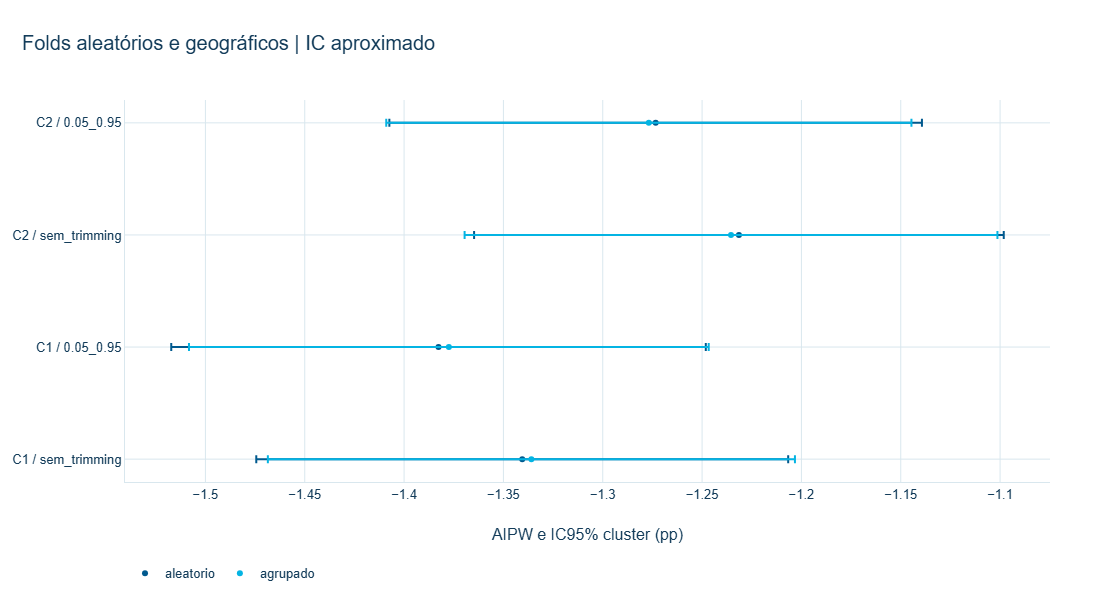

In [11]:
display(pd.DataFrame([{k:v for k,v in f.items() if k!='ajustes'} for f in geografico['folds']]))
comparacao=pd.DataFrame([dict(folds=k,**r) for k in ['aleatorio','agrupado'] for r in geografico[k]['resultados']])
display(comparacao[['folds']+colunas].round(6))
display(pd.DataFrame([dict(folds=k,especificacao=s,AUC=d['propensity']['roc_auc'],Brier=d['propensity']['brier'])
    for k in ['aleatorio','agrupado'] for s,d in geografico[k]['nuisance'].items()]).round(6))
fig=go.Figure()
for k in ['aleatorio','agrupado']:
    d=comparacao[comparacao.folds==k]
    fig.add_scatter(x=d.estimativa_pp,y=d.especificacao+' / '+d.populacao,mode='markers',name=k,
        error_x=dict(type='data',symmetric=False,array=d.ic95_cluster_superior_pp-d.estimativa_pp,
                     arrayminus=d.estimativa_pp-d.ic95_cluster_inferior_pp))
fig.update_xaxes(title='AIPW e IC95% cluster (pp)')
mostrar(fig,'Folds aleatórios e geográficos | IC aproximado','crossfit')


In [12]:
diagnosticos=[]
performance=[]
for k in ['aleatorio','agrupado']:
    for r in geografico[k]['resultados']:
        diagnosticos.append(dict(folds=k,especificacao=r['especificacao'],populacao=r['populacao'],
            n=r['n'],ESS_T0=r['ess']['0']['ess'],ESS_T1=r['ess']['1']['ess'],top1_IF2=r['top1_if2']))
    for s,d in geografico[k]['nuisance'].items():
        for g,m in d['outcomes'].items():
            performance.append(dict(folds=k,especificacao=s,grupo=g,AUC=m['roc_auc'],AP=m['pr_auc_ap'],Brier=m['brier']))
display(pd.DataFrame(diagnosticos).round(4))
display(pd.DataFrame(performance).round(6))


,folds,especificacao,populacao,n,ESS_T0,ESS_T1,top1_IF2
0,aleatorio,C1,sem_trimming,2251570,232772.2408,1.927133e+06,0.7878
1,aleatorio,C1,0.05_0.95,2103319,244237.0723,1.787300e+06,0.7615
2,aleatorio,C2,sem_trimming,2251570,232772.2408,1.927133e+06,0.7877
3,aleatorio,C2,0.05_0.95,2103319,244237.0723,1.787300e+06,0.7609
4,agrupado,C1,sem_trimming,2251570,232082.7622,1.926748e+06,0.7903
5,agrupado,C1,0.05_0.95,2101625,244168.6096,1.785614e+06,0.7631
6,agrupado,C2,sem_trimming,2251570,232082.7622,1.926748e+06,0.7897
7,agrupado,C2,0.05_0.95,2101625,244168.6096,1.785614e+06,0.7621


,folds,especificacao,grupo,AUC,AP,Brier
0,aleatorio,C1,0,0.583803,0.120885,0.082281
1,aleatorio,C1,1,0.571815,0.096928,0.070736
2,aleatorio,C2,0,0.588761,0.122982,0.082204
3,aleatorio,C2,1,0.580691,0.101489,0.070630
4,agrupado,C1,0,0.583460,0.120338,0.082295
5,agrupado,C1,1,0.570738,0.096655,0.070745
6,agrupado,C2,0,0.588449,0.122379,0.082216
7,agrupado,C2,1,0.579632,0.100854,0.070646


## 9. Leave-one-UF-out

Retira os registros de uma UF por vez, mantendo nuisances OOF. É diagnóstico de estabilidade da média padronizada, **não heterogeneidade causal**. Não reajusta 27 modelos.


estimativa_pp           mudanca_pp          
especificacao               C1        C2         C1        C2
grupo n_removido                                             
11    18782          -1.338634 -1.229635   0.001893  0.001821
12    11862          -1.347241 -1.238140  -0.006714 -0.006684
13    62614          -1.358348 -1.248704  -0.017821 -0.017248
14    11105          -1.338846 -1.230371   0.001681  0.001085
15    108354         -1.350720 -1.239265  -0.010193 -0.007809
16    11746          -1.347738 -1.238228  -0.007211 -0.006773
17    21119          -1.341928 -1.232665  -0.001402 -0.001210
21    86044          -1.353563 -1.244111  -0.013036 -0.012655
22    36612          -1.323972 -1.214867   0.016554  0.016589
23    95379          -1.347422 -1.242930  -0.006895 -0.011474
24    34611          -1.366434 -1.257063  -0.025907 -0.025608
25    45121          -1.354118 -1.244603  -0.013591 -0.013148
26    104748         -1.331778 -1.223380   0.008749  0.008076
27    43786          -1.345724 -1.236231  -0.005197 -0.004775
28    26296          -1.347572 -1.238471  -0.007046 -0.007015
29    147071         -1.352421 -1.244272  -0.011895 -0.012816
31    204343         -1.296451 -1.191472   0.044076  0.039984
32    47804          -1.309596 -1.199536   0.030930  0.031919
33    154987         -1.324167 -1.216666   0.016360  0.014790
35    449148         -1.247043 -1.132881   0.093484  0.098574
41    124944         -1.339554 -1.229059   0.000973  0.002396
42    90688          -1.353739 -1.245374  -0.013212 -0.013918
43    107292         -1.376231 -1.267428  -0.035704 -0.035972
50    36503          -1.330867 -1.220786   0.009660  0.010670
51    53061          -1.360362 -1.250566  -0.019836 -0.019110
52    85511          -1.345737 -1.237638  -0.005210 -0.006182
53    32039          -1.345132 -1.235601  -0.004605 -0.004145

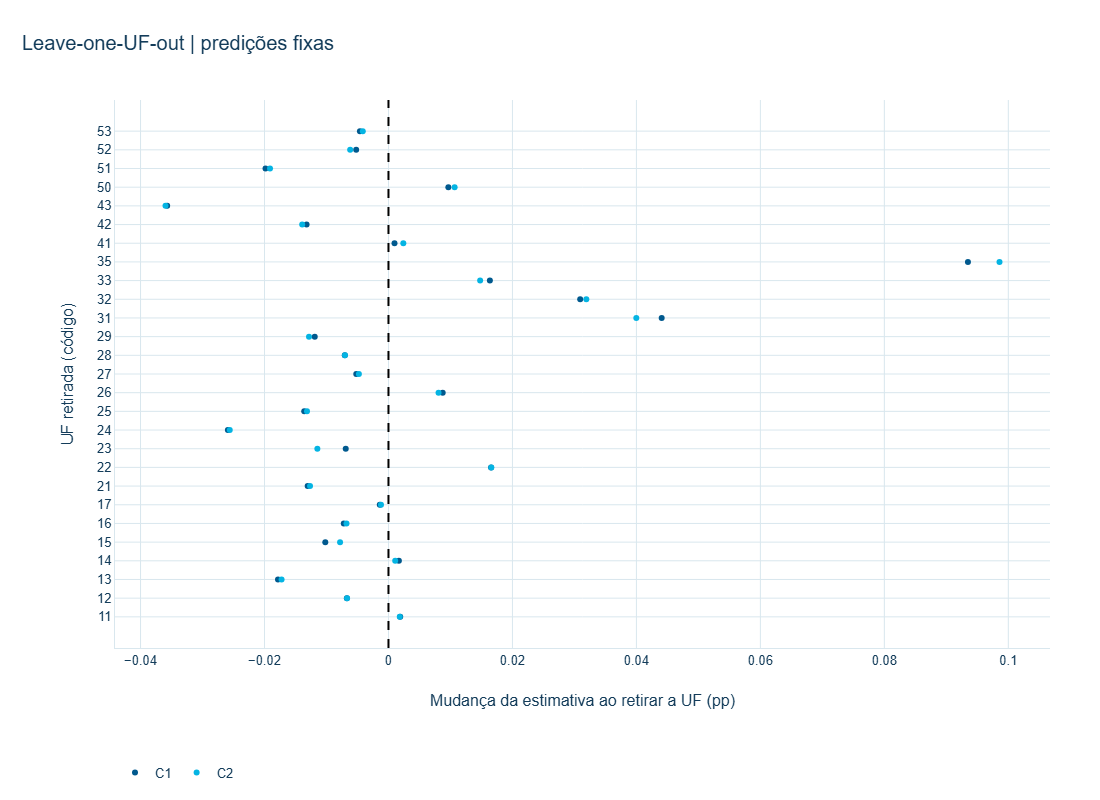

In [13]:
loo=pd.DataFrame(influencia['leave_one_uf_out'])
display(loo.pivot(index=['grupo','n_removido'],columns='especificacao',values=['estimativa_pp','mudanca_pp']).round(6))
fig=go.Figure()
for s in ['C1','C2']:
    d=loo[loo.especificacao==s]
    fig.add_scatter(x=d.mudanca_pp,y=d.grupo,mode='markers',name=s)
fig.add_vline(x=0,line_dash='dash')
fig.update_xaxes(title='Mudança da estimativa ao retirar a UF (pp)')
fig.update_yaxes(title='UF retirada (código)',type='category')
mostrar(fig,'Leave-one-UF-out | predições fixas','leave_uf',800)


São Paulo (35) produz a maior mudança, cerca de +0,09–0,10 pp. O sinal permanece negativo em todas as exclusões. Participação geográfica não implica mecanismo causal.

## 10. Monte Carlo do gate

Quatro cenários fixos, N=50.000, 200 réplicas cada, seed 20240925+j. Efeito verdadeiro −1 pp; nuisances oráculo. S1: e=0,5 e prevalência 10%; S2: e=0,85 e prevalência 10%; S3: e entre 0,75 e 0,95 e prevalência 8%; S4: 20% da população com e=0,995, restante e=0,81375.

O oráculo isola a heurística; não reproduz incerteza do ajuste, agrupamento ou seleção SINASC. Frequência empírica 0/100% não significa probabilidade populacional exatamente 0/1.


,cenario,bias_pp,mcse_bias_pp,rmse_pp,cobertura,mcse_cobertura,prob_gate,ess_t0_medio
0,S1,0.027424,0.017913,0.254177,0.960,0.013856,0.00,24988.580000
1,S2,0.001414,0.028767,0.405810,0.950,0.015411,0.02,7486.700000
2,S3,-0.073079,0.026096,0.375312,0.975,0.011040,1.00,6215.628502
3,S4,-0.087381,0.071764,1.016127,0.895,0.021677,1.00,1140.967141


,cenario,prob_gate,IC_MC_inferior,IC_MC_superior
0,S1,0.00,0.0000,0.0183
1,S2,0.02,0.0055,0.0504
2,S3,1.00,0.9817,1.0000
3,S4,1.00,0.9817,1.0000


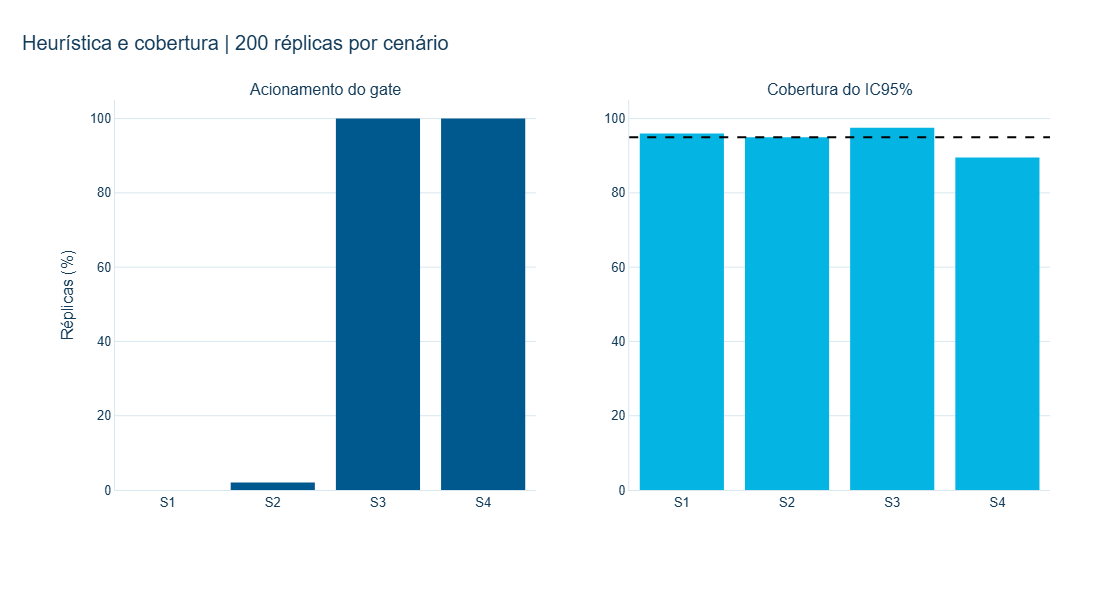

In [14]:
from scipy.stats import binomtest
mc=pd.DataFrame([{k:v for k,v in s.items() if k!='replicas'} for s in monte_carlo['cenarios']])
for campo in ['bias','rmse','mcse_bias']: mc[campo+'_pp']=100*mc[campo]
display(mc[['cenario','bias_pp','mcse_bias_pp','rmse_pp','cobertura','mcse_cobertura','prob_gate','ess_t0_medio']].round(6))
intervalos=[binomtest(round(s['prob_gate']*s['n_replicas']),s['n_replicas']).proportion_ci() for s in monte_carlo['cenarios']]
display(pd.DataFrame([dict(cenario=s['cenario'],prob_gate=s['prob_gate'],IC_MC_inferior=i.low,IC_MC_superior=i.high)
    for s,i in zip(monte_carlo['cenarios'],intervalos)]).round(4))
fig=make_subplots(rows=1,cols=2,subplot_titles=['Acionamento do gate','Cobertura do IC95%'])
fig.add_bar(x=mc.cenario,y=100*mc.prob_gate,name='Gate',showlegend=False,row=1,col=1)
fig.add_bar(x=mc.cenario,y=100*mc.cobertura,name='Cobertura',showlegend=False,row=1,col=2)
fig.add_hline(y=95,line_dash='dash',row=1,col=2)
fig.update_yaxes(title='Réplicas (%)',range=[0,105],row=1,col=1)
fig.update_yaxes(range=[0,105],row=1,col=2)
mostrar(fig,'Heurística e cobertura | 200 réplicas por cenário','monte_carlo')


S3 aciona o gate em todas as réplicas, com cobertura de 97,5%; S4 também aciona em todas, mas com cobertura de 89,5%. A regra isolada não distingue esses casos. O bias estimado em S3 foi −0,073 pp (MCSE 0,026 pp); não se repetiu a simulação para buscar um resultado mais conveniente.

## 11. Sensibilidade CONSPRENAT=0

S1 exclui discordâncias mês válido/zero consultas. Reajusta C1/C2 na população restrita. T permanece definido por MESPRENAT; consultas não entram em X. A exclusão também é seleção posterior, não uma correção causal demonstrada.


In [15]:
display(pd.DataFrame([{k:v for k,v in sens['amostras'][s].items() if k not in ['sql','codigos_municipio_nao_especificado']} for s in ['P1','CONSPRENAT']])[['cenario','n','n_t1','n_t0','prevalencia','n_consprenat_zero']]); tabela(sens['CONSPRENAT'])

,cenario,n,n_t1,n_t0,prevalencia,n_consprenat_zero
0,P1,2251570,1942045,309525,0.078949,1064
1,CONSPRENAT,2250506,1941385,309121,0.078891,0


,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,C1,sem_trimming,2250506,-1.330146,0.061996,0.068663,-1.464752,-1.195541
1,C1,0.05_0.95,2102367,-1.368032,0.060811,0.068992,-1.503282,-1.232782
2,C2,sem_trimming,2250506,-1.220837,0.061982,0.068532,-1.355186,-1.086489
3,C2,0.05_0.95,2102367,-1.257726,0.060781,0.068934,-1.392863,-1.122588


## 12. Sensibilidade de peso P0

Todos os pesos numéricos positivos; gestação única. Mesmo Y<2.500 g, X e T. Nuisances reajustados. Valores extremos podem incluir erro de mensuração; P0 não substitui P1.


In [16]:
display(pd.DataFrame([{k:v for k,v in sens['amostras']['P0'].items() if k not in ['sql','codigos_municipio_nao_especificado']}])[['n','prevalencia','n_peso_fora_p1']]); tabela(sens['P0'])

,n,prevalencia,n_peso_fora_p1
0,2254701,0.080204,3131


,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,C1,sem_trimming,2254701,-1.316646,0.062302,0.068710,-1.451343,-1.181948
1,C1,0.05_0.95,2106146,-1.358046,0.061124,0.069006,-1.493325,-1.222767
2,C2,sem_trimming,2254701,-1.213659,0.062281,0.068556,-1.348056,-1.079263
3,C2,0.05_0.95,2106146,-1.253563,0.061096,0.069002,-1.388834,-1.118291


## 13. Sensibilidade a múltiplas

GRAVIDEZ 1/2/3, peso P1. Cada nascido vivo permanece uma linha; múltiplas podem gerar irmãos correlacionados sem identificador da gestação. Reportar estabilidade direcional/magnitude, sem equivalência com a população principal.


In [17]:
display(pd.DataFrame([{k:v for k,v in sens['amostras']['MULTIPLAS'].items() if k not in ['sql','codigos_municipio_nao_especificado']}])[['n','prevalencia','n_multipla']]); tabela(sens['MULTIPLAS'])

,n,prevalencia,n_multipla
0,2304013,0.091521,52443


,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,C1,sem_trimming,2304013,-1.133412,0.065180,0.075878,-1.282164,-0.984661
1,C1,0.05_0.95,2147344,-1.192948,0.063529,0.075004,-1.339985,-1.045910
2,C2,sem_trimming,2304013,-1.027203,0.065154,0.075711,-1.175626,-0.878780
3,C2,0.05_0.95,2147344,-1.084863,0.063496,0.074953,-1.231800,-0.937925


,cenario,especificacao,n,estimativa_pp,diferenca_p1_pp,diferenca_relativa_abs_p1
0,CONSPRENAT,C1,2250506,-1.330146,0.010381,0.007744
1,CONSPRENAT,C2,2250506,-1.220837,0.010618,0.008623
2,P0,C1,2254701,-1.316646,0.023881,0.017815
3,P0,C2,2254701,-1.213659,0.017797,0.014452
4,MULTIPLAS,C1,2304013,-1.133412,0.207114,0.154502
5,MULTIPLAS,C2,2304013,-1.027203,0.204253,0.165863


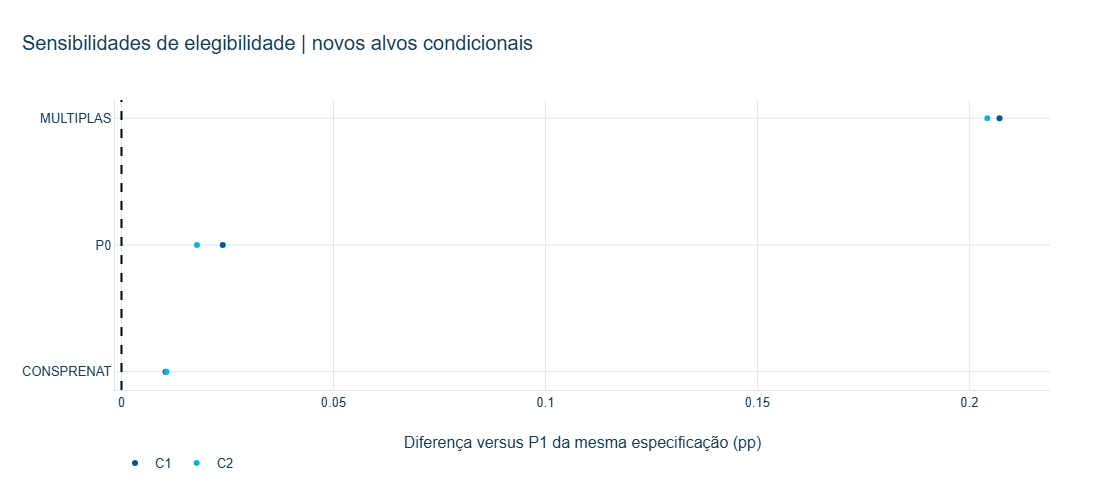

In [18]:
resumos=pd.DataFrame([dict(cenario=k,**r) for k in ['CONSPRENAT','P0','MULTIPLAS'] for r in sens[k]['resultados'] if r['populacao']=='sem_trimming'])
display(resumos[['cenario','especificacao','n','estimativa_pp','diferenca_p1_pp','diferenca_relativa_abs_p1']].round(6))
fig=go.Figure()
for s in ['C1','C2']:
    d=resumos[resumos.especificacao==s]
    fig.add_scatter(x=d.diferenca_p1_pp,y=d.cenario,mode='markers',name=s)
fig.add_vline(x=0,line_dash='dash')
fig.update_xaxes(title='Diferença versus P1 da mesma especificação (pp)')
mostrar(fig,'Sensibilidades de elegibilidade | novos alvos condicionais','elegibilidade',500)


## 14. C3: propensity não linear

HGB para e; outcomes HGB C2 históricos, com os mesmos folds aleatórios. Reutilizar esses outcomes mantém previsões OOF adequadas e isola a mudança de propensity. Hiperparâmetros congelados, sem tuning. AUC/Brier medem nuisances, não qualidade causal.


In [19]:
tabela(sens['S0'])
display(pd.DataFrame([dict(especificacao=s,AUC=d['propensity']['roc_auc'],Brier=d['propensity']['brier'],
    suporte_min=d['overlap']['suporte_comum_observado']['inferior'],suporte_max=d['overlap']['suporte_comum_observado']['superior'])
    for s,d in sens['S0']['nuisance'].items()]).round(6))
display(pd.DataFrame([dict(especificacao=r['especificacao'],populacao=r['populacao'],top1_IF2=r['top1_if2'],
    ESS_T0=r['ess']['0']['ess'],ESS_T1=r['ess']['1']['ess'],peso_max_T0=r['ess']['0']['max']) for r in sens['S0']['resultados']]).round(6))


,especificacao,populacao,n,estimativa_pp,se_iid_pp,se_cluster_pp,ic95_cluster_inferior_pp,ic95_cluster_superior_pp
0,C1,sem_trimming,2251570,-1.340527,0.061994,0.068287,-1.474397,-1.206657
1,C1,0.05_0.95,2103319,-1.382662,0.060840,0.068626,-1.517196,-1.248127
2,C2,sem_trimming,2251570,-1.231456,0.061981,0.067997,-1.364757,-1.098155
3,C2,0.05_0.95,2103319,-1.273369,0.060813,0.068371,-1.407403,-1.139335
4,C3,sem_trimming,2251570,-1.232469,0.061044,0.067628,-1.365046,-1.099892
5,C3,0.05_0.95,2096706,-1.250146,0.060684,0.069204,-1.385813,-1.114480


,especificacao,AUC,Brier,suporte_min,suporte_max
0,C1,0.662862,0.113490,0.29845,0.974221
1,C2,0.662862,0.113490,0.29845,0.974221
2,C3,0.671222,0.112829,0.28872,0.976008


,especificacao,populacao,top1_IF2,ESS_T0,ESS_T1,peso_max_T0
0,C1,sem_trimming,0.787812,232772.240802,1.927133e+06,38.791759
1,C1,0.05_0.95,0.761472,244237.072311,1.787300e+06,19.995383
2,C2,sem_trimming,0.787666,232772.240802,1.927133e+06,38.791759
3,C2,0.05_0.95,0.760897,244237.072311,1.787300e+06,19.995383
4,C3,sem_trimming,0.790267,233219.782769,1.924962e+06,41.679717
5,C3,0.05_0.95,0.764929,243400.209926,1.778189e+06,19.997666


## 15. Auditoria do estimando

O estimador descreve um contraste padronizado na distribuição selecionada de nascidos vivos. Nascimento vivo, peso disponível e mês registrado são critérios conhecidos posteriormente à decisão de iniciar pré-natal. Multiplicidade registrada ao final não prova, por si só, causalidade pós-tratamento; seleção por sobrevivência fetal também precisa ser considerada.

Não identifica automaticamente efeito em todas as concepções ou no estrato que nasceria vivo sob ambas as exposições. Estabilidade, dupla robustez e IC estreito não resolvem essas hipóteses. [Auditoria completa](../docs/methodology/AUDITORIA_ESTIMANDO_FASE3.md).

## 16. Síntese

Reconciliação independente, concentração, geografia e sensibilidades respondem perguntas diferentes. Não usar significância como critério principal; nenhuma especificação será promovida por produzir o efeito desejado.


In [20]:
display(pd.DataFrame(gate['evidencias'])); display(Markdown(gate['sintese']))

,dimensao,evidencia,limite
0,Literatura,13 referências; não localizado fundamento para...,"Busca dirigida, não sistemática"
1,Implementação,Seis combinações históricas reproduzidas; delt...,Corretude computacional não identifica causali...
2,Influência,"Top 1% ~78,8%; máximo individual <0,06% de IF²...",Concentração coletiva merece diagnóstico; não ...
3,Inferência geográfica,SE municipal aumenta ~10%; bootstrap condicion...,Independência entre municípios e incerteza com...
4,Ajuste geográfico,Três folds sem cluster compartilhado; mudança ...,Uma partição; DF ausente de um treino externo
5,Monte Carlo,"S3: gate 100%, cobertura 97,5%; S4: gate 100%,...",200 réplicas/cenário; oráculo iid não valida o...
6,C3,"Propensity HGB: -1,232469 pp, próximo de C2 -1...",Estabilidade entre modelos não exclui viés comum
7,Elegibilidade,"CONSPRENAT muda ~0,01 pp; P0 ~0,02 pp; múltipl...",Múltiplas têm alvo e dependência distintos; nã...
8,Estimando,Contraste padronizado na população selecionada...,Não identifica efeito em todas as concepções n...


O veto automático pelo top 1% >50% de IF² é excessivamente conservador como diagnóstico de invalidade numérica/inferencial. AIPW histórico reconciliado, contribuição individual pequena, ajustes geográficos estáveis e simulação oráculo questionam esse veto. A inclusão de múltiplas muda a magnitude em cerca de 0,20 pp e define outro alvo. Seleção, confundimento e temporalidade continuam impedindo uma interpretação causal forte; o gate histórico não foi alterado.

## 17. Gate Fase 3

A revisão é adicional. O registro histórico da Fase 2 não foi editado. [Literatura e fórmulas](../docs/literature/AUDITORIA_GATE_INFLUENCIA.md); [relatório completo](../docs/methodology/ROBUSTEZ_FASE3.md).


In [21]:
assert historico['gate']=='RESULTADO_NAO_INTERPRETAVEL'
assert gate['historico_fase2']=='RESULTADO_NAO_INTERPRETAVEL'
assert validacao['historico_intacto']
display(Markdown('**GATE_REVISAO_FASE3 = '+gate['gate']+'**'))
print('Sem CATE, Causal Forest ou uplift. Causalidade não provada.')


**GATE_REVISAO_FASE3 = GATE_FASE2_EXCESSIVAMENTE_CONSERVADOR**

Sem CATE, Causal Forest ou uplift. Causalidade não provada.
